In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Hassan Darwish 
## A2. Logistic Map

In [3]:
# params
r = 3.9
iters = 1500
x = [0.5]

In [4]:
for n in range(1, iters):
    x.append(r*x[n-1]*(1-x[n-1]))
x = x[500:]
n = np.arange(500, iters)

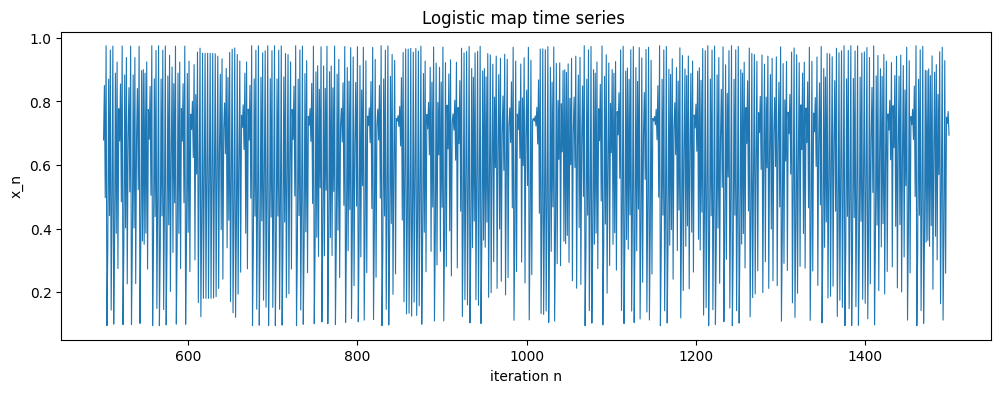

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(n, x, lw=0.8)
plt.xlabel("iteration n")
plt.ylabel("x_n")
plt.title(f"Logistic map time series ")
plt.show()

## A4. Logistic Map Bifurcation 

In [6]:
# params
transient = 500
r_values = np.arange(2.5, 4, 0.003)
iters = 1500

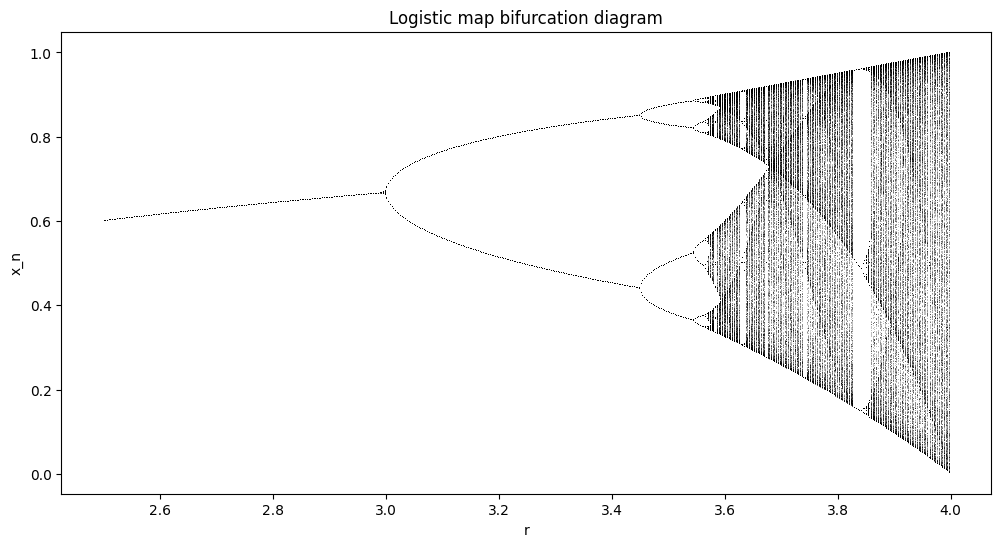

In [7]:
rs, xs = [], []

for r in r_values:
    x = 0.5                          
    for i in range(iters):
        x = r * x * (1 - x)          
        if i >= transient:        
            rs.append(r)
            xs.append(x)
            
plt.figure(figsize=(12, 6))
plt.plot(rs, xs, ',k', alpha=0.25)
plt.xlabel("r")
plt.ylabel("x_n")
plt.title("Logistic map bifurcation diagram")
plt.show()

## A3. Henon Map

In [8]:
# params
a = 1.4
b = 0.3
iters = 5500
x, y = [0], [0]

In [9]:
for n in range(1,iters):
    x.append(1-a*(x[n-1]**2)+y[n-1])
    y.append(b*x[n-1])
x = x[500:]
y = y[500:]   

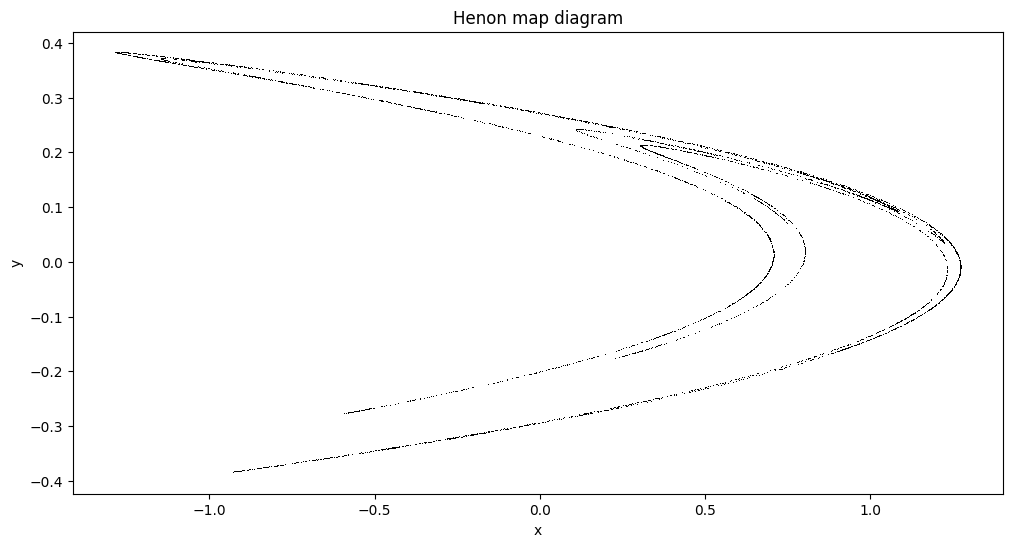

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(x, y, ',k')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Henon map diagram")
plt.show()

# A4. Henen Map Bifurcation  

In [11]:
a_values = np.arange(1, 1.4, 0.003)
iters = 5500
transient = 500

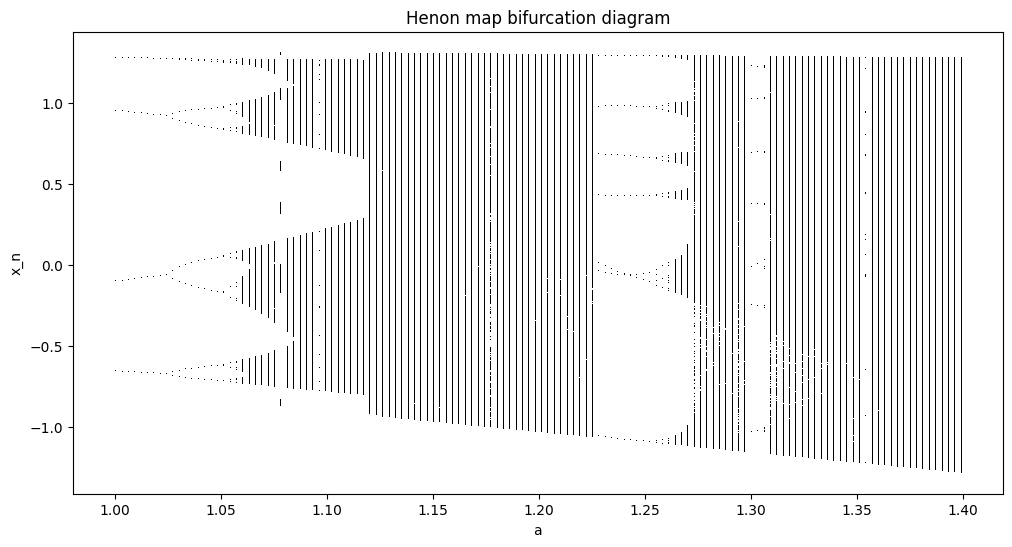

In [12]:
af, xs = [], []

for a in a_values:
    x = 0
    y = 0                      
    for i in range(iters):
        x_new = 1-a*(x**2)+y
        y_new = b*x
        x, y = x_new, y_new
        if i >= transient:        
            af.append(a)
            xs.append(x)
            
plt.figure(figsize=(12, 6))
plt.plot(af, xs, ',k')
plt.xlabel("a")
plt.ylabel("x_n")
plt.title("Henon map bifurcation diagram")
plt.show()

## B2. Lorenz Map

In [13]:
# params
sigma, rho, beta = 10.0, 28.0, 8/3
T = 50
dt = 0.01

In [14]:
def lorenz(t, s):                      
    x, y, z = s
    return [sigma*(y - x),
            x*(rho - z) - y,
            x*y - beta*z]

In [15]:
t_eval = np.arange(0, T, dt)

sol = solve_ivp(lorenz, [0, T], [1.0, 1.0, 1.0],
                method='RK45', t_eval=t_eval, rtol=1e-9, atol=1e-9)

t = sol.t
x, y, z = sol.y                      

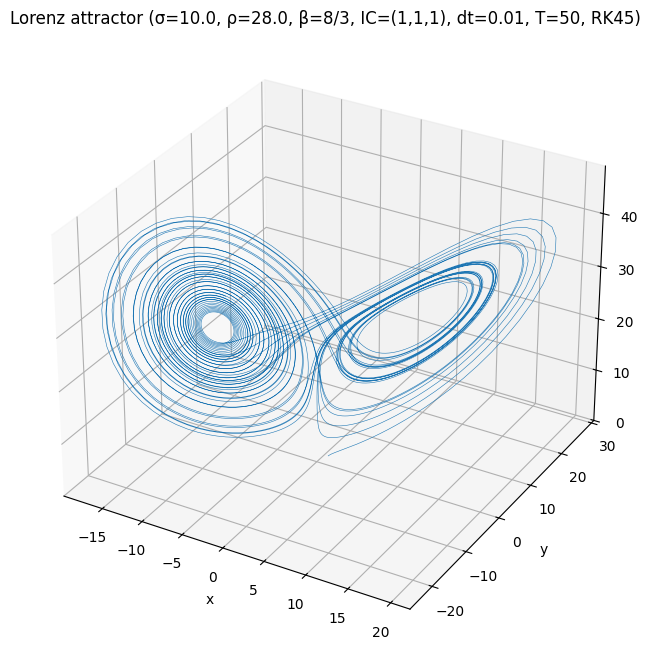

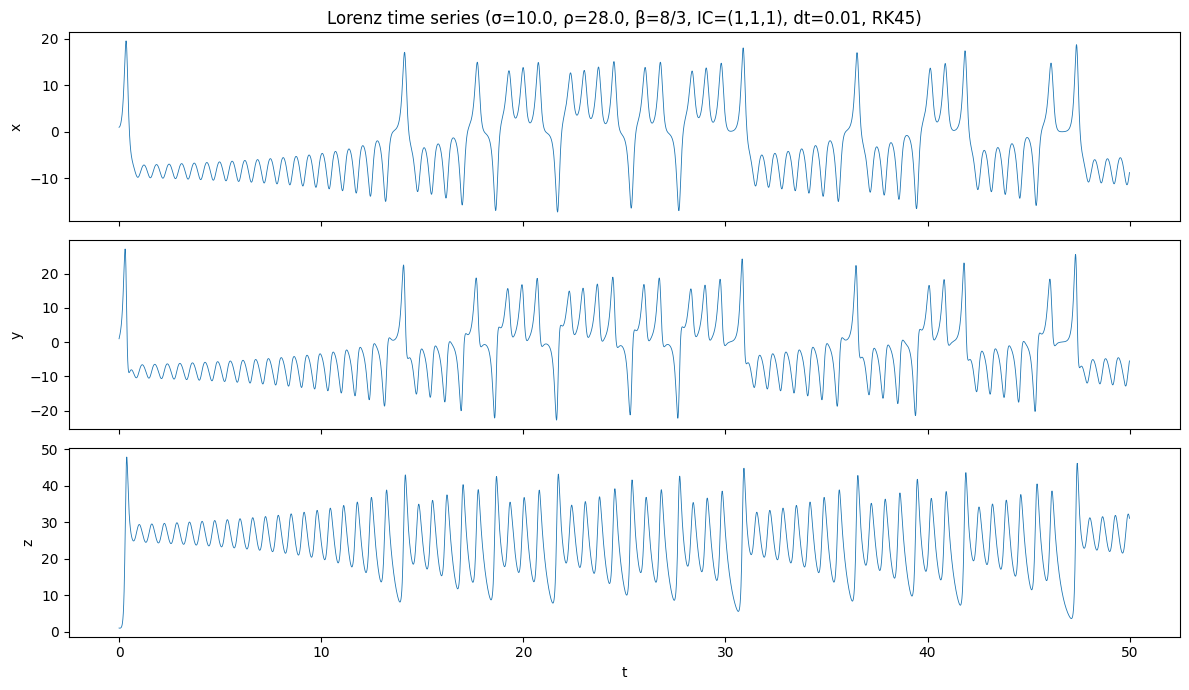

In [16]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, lw=0.4)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"Lorenz attractor (σ={sigma}, ρ={rho}, β=8/3, IC=(1,1,1), dt={dt}, T={T}, RK45)")
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, series, name in zip(axes, [x, y, z], ['x', 'y', 'z']):
    ax.plot(t, series, lw=0.6)
    ax.set_ylabel(name)
axes[-1].set_xlabel("t")
axes[0].set_title(f"Lorenz time series (σ={sigma}, ρ={rho}, β=8/3, IC=(1,1,1), dt={dt}, RK45)")
plt.tight_layout()
plt.show()

## B3. Rossler Map

In [17]:
# params
a, b, c = 0.2, 0.2, 5.7
T = 300
dt = 0.01

In [18]:
def rossler(t, s):                      
    x, y, z = s
    return [-y-z,
            x + a*y,
            b + z*(x - c)]

In [19]:
t_eval = np.arange(0, T, dt)

sol = solve_ivp(rossler, [0, T], [1.0, 1.0, 1.0],
                method='RK45', t_eval=t_eval, rtol=1e-9, atol=1e-9)

t = sol.t
x, y, z = sol.y                      

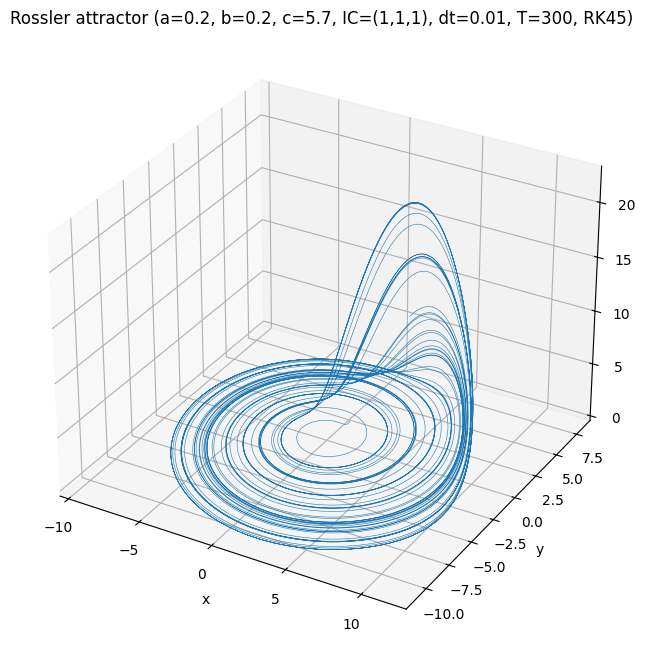

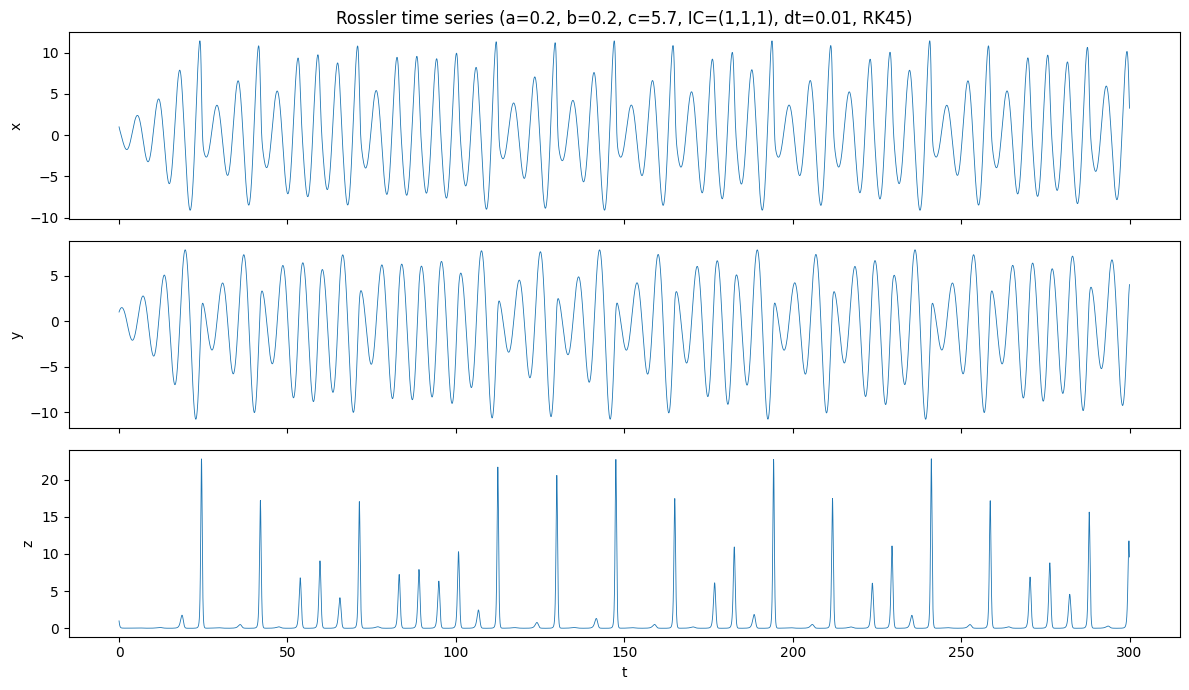

In [20]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, lw=0.4)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"Rossler attractor (a={a}, b={b}, c={c}, IC=(1,1,1), dt={dt}, T={T}, RK45)")
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, series, name in zip(axes, [x, y, z], ['x', 'y', 'z']):
    ax.plot(t, series, lw=0.6)
    ax.set_ylabel(name)
axes[-1].set_xlabel("t")
axes[0].set_title(f"Rossler time series (a={a}, b={b}, c={c}, IC=(1,1,1), dt={dt}, RK45)")
plt.tight_layout()
plt.show()

## Chen Map

In [21]:
# params
a, b, c = 35 , 3, 28
T = 50
dt = 0.003

In [22]:
def chen(t, s):                      
    x, y, z = s
    return [a*(y - x),
            x*(c - a) - x*z + c*y,
            x*y - b*z]

In [23]:
print(a, b, c)

35 3 28


In [24]:
t_eval = np.arange(0, T, dt)

sol = solve_ivp(chen, [0, T], [-0.1, 0.5, -0.6],
                method='RK45', t_eval=t_eval, rtol=1e-9, atol=1e-9)

t = sol.t
x, y, z = sol.y                      

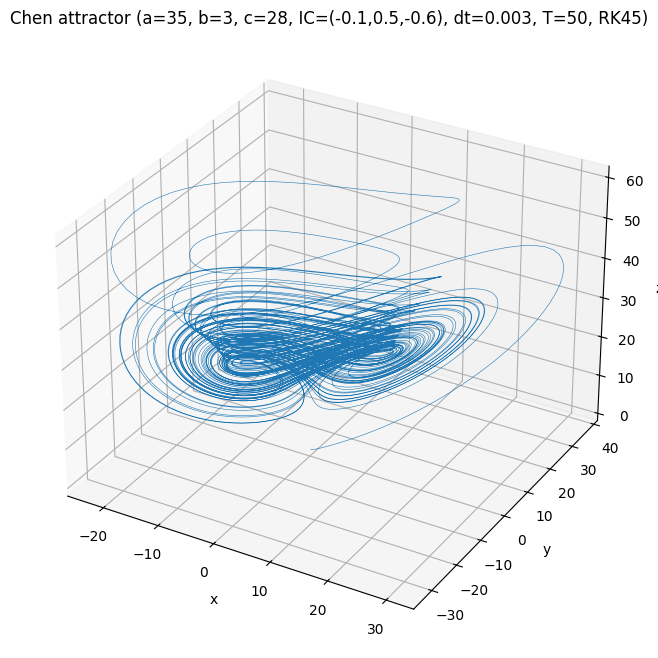

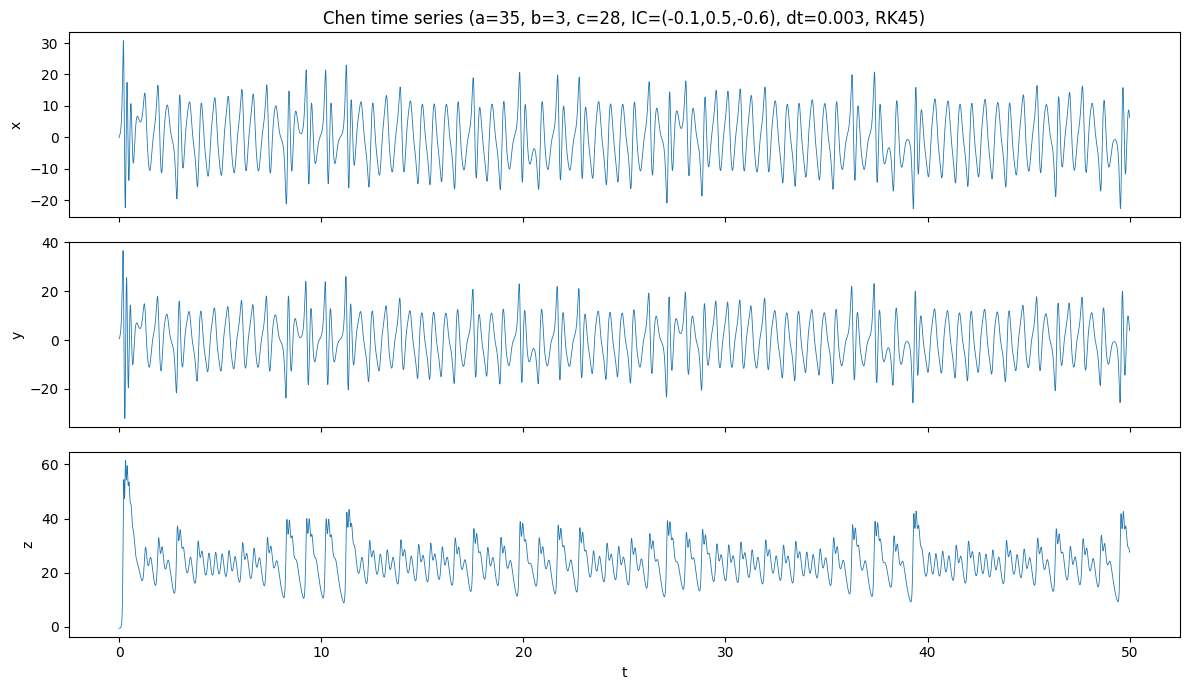

In [25]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, lw=0.4)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"Chen attractor (a={a}, b={b}, c={c}, IC=(-0.1,0.5,-0.6), dt={dt}, T={T}, RK45)")
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, series, name in zip(axes, [x, y, z], ['x', 'y', 'z']):
    ax.plot(t, series, lw=0.6)
    ax.set_ylabel(name)
axes[-1].set_xlabel("t")
axes[0].set_title(f"Chen time series (a={a}, b={b}, c={c}, IC=(-0.1,0.5,-0.6), dt={dt}, RK45)")
plt.tight_layout()
plt.show()

## Hyperchaotic Rössler Map

In [26]:
T = 250
dt = 0.01
ic = [-10.0, -6.0, 0.0, 10.0]

In [27]:
def hyper_rossler(t, s, a=0.25, b=3.0, c=0.5, d=0.05):
    x, y, z, w = s
    return [-y - z,
            x + a*y + w,
            b + x*z,
            -c*z + d*w]

In [28]:
t_eval = np.arange(0, T, dt)

sol = solve_ivp(hyper_rossler, [0, T], ic,
                method='RK45', t_eval=t_eval, rtol=1e-9, atol=1e-9)

t = sol.t
x, y, z, w = sol.y

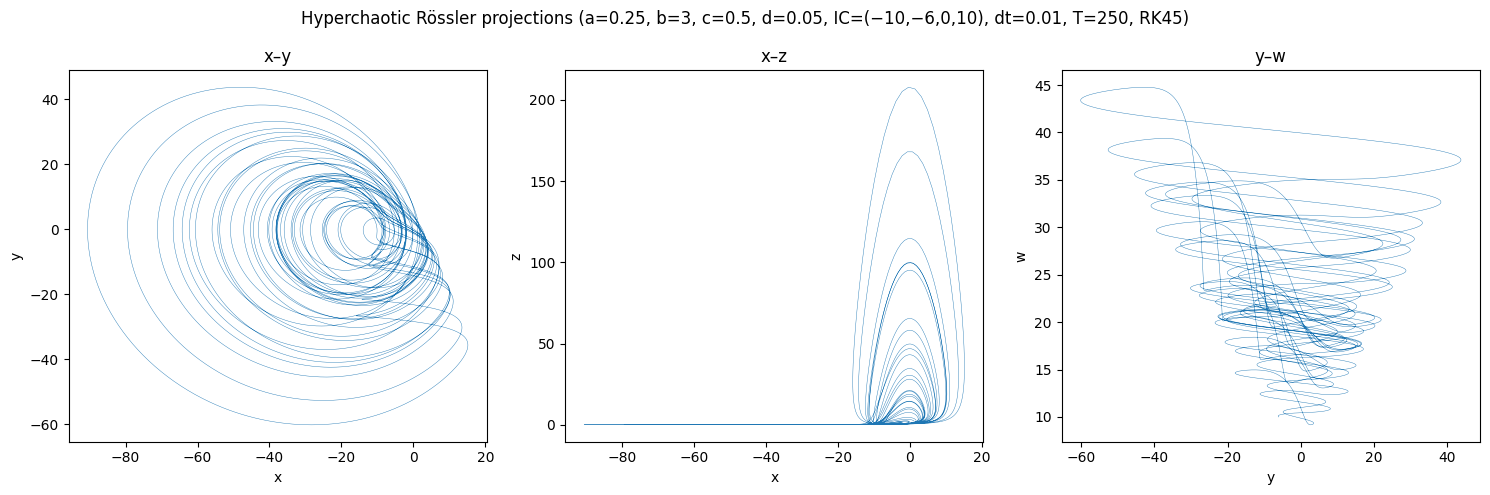

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (u, v, un, vn) in zip(axes, [(x, y, 'x', 'y'),
                                      (x, z, 'x', 'z'),
                                      (y, w, 'y', 'w')]):
    ax.plot(u, v, lw=0.3)
    ax.set_xlabel(un); ax.set_ylabel(vn)
    ax.set_title(f"{un}–{vn}")
fig.suptitle("Hyperchaotic Rössler projections (a=0.25, b=3, c=0.5, d=0.05, IC=(−10,−6,0,10), dt=0.01, T=250, RK45)")
plt.tight_layout()
plt.show()

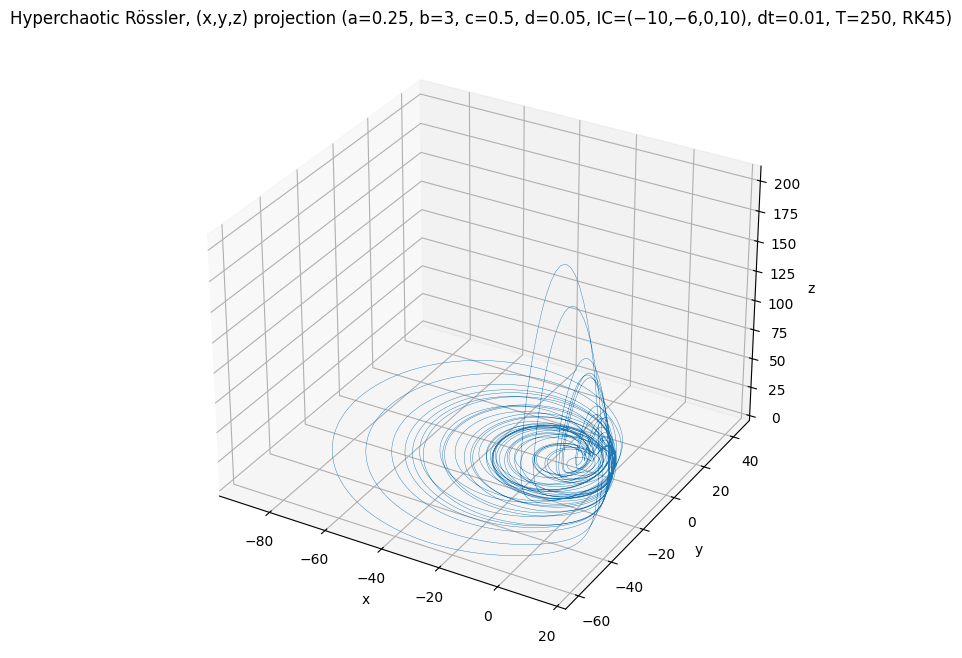

In [30]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, lw=0.3)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Hyperchaotic Rössler, (x,y,z) projection (a=0.25, b=3, c=0.5, d=0.05, IC=(−10,−6,0,10), dt=0.01, T=250, RK45)")
plt.show()

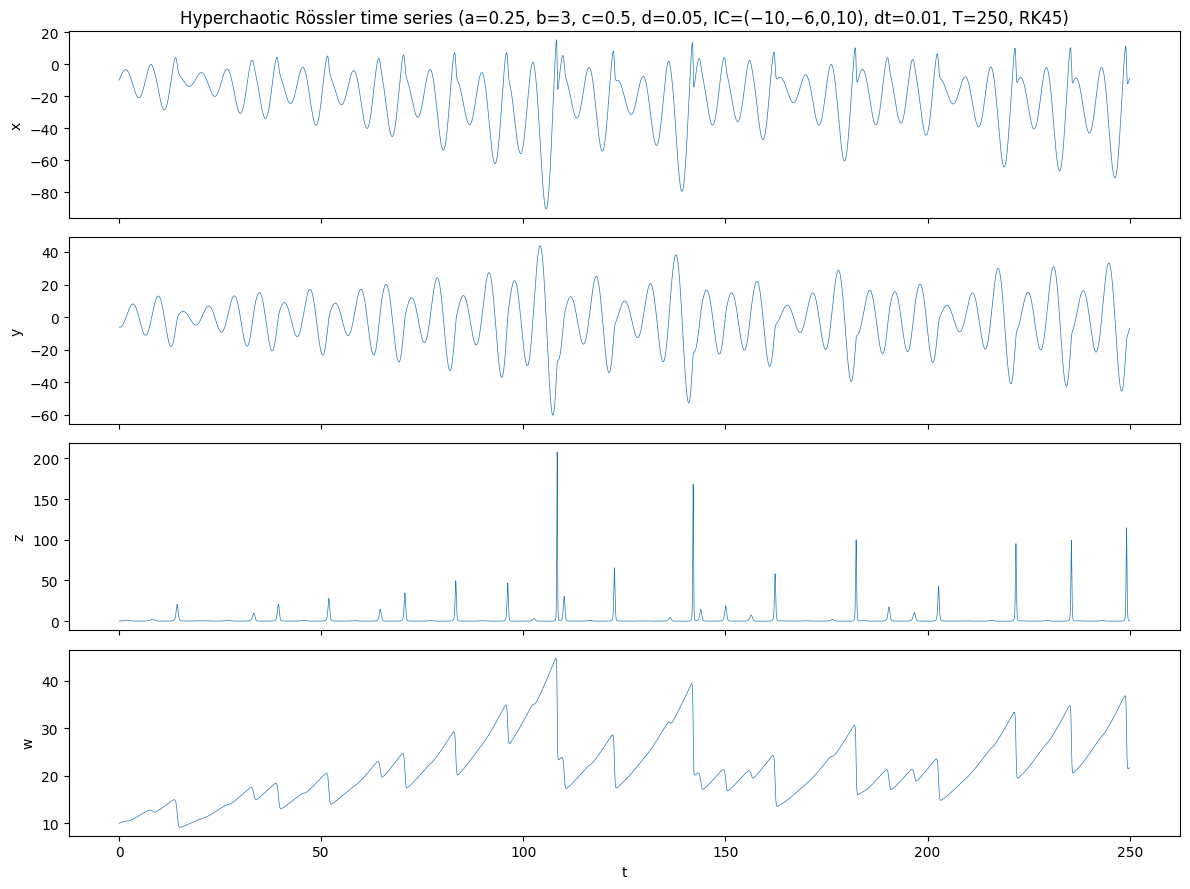

In [31]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, series, name in zip(axes, [x, y, z, w], ['x', 'y', 'z', 'w']):
    ax.plot(t, series, lw=0.5)
    ax.set_ylabel(name)
axes[-1].set_xlabel("t")
axes[0].set_title("Hyperchaotic Rössler time series (a=0.25, b=3, c=0.5, d=0.05, IC=(−10,−6,0,10), dt=0.01, T=250, RK45)")
plt.tight_layout()
plt.show()

## C1. Lorenz Map (Parameter sweep)

In [32]:
sigma, beta = 10.0, 8/3
rho_values = np.arange(0, 30, 0.2)
T = 100
dt = 0.01
transient_t = 20          
ic = [1.0, 1.0, 1.0]

In [33]:
def lorenz_rho(t, s, rho, sigma=10.0, beta=8/3):
    x, y, z = s
    return [sigma*(y - x),
            x*(rho - z) - y,
            x*y - beta*z]

In [34]:
t_eval = np.arange(0, T, dt)
rhos, maxima = [], []

In [35]:
for rho in rho_values:
    sol = solve_ivp(lorenz_rho, [0, T], ic, args=(rho,),
                    method='RK45', t_eval=t_eval, rtol=1e-9, atol=1e-9)
    z = sol.y[2]
    keep = sol.t >= transient_t          # discard transient
    z = z[keep]

    # local maxima: z[i-1] < z[i] > z[i+1]
    for i in range(1, len(z)-1):
        if z[i-1] < z[i] > z[i+1]:
            rhos.append(rho)
            maxima.append(z[i])

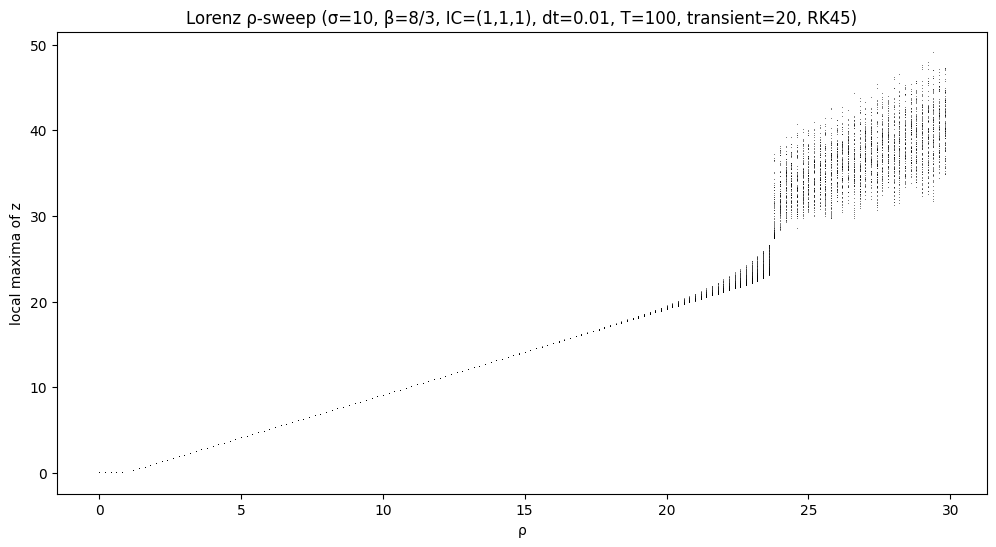

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(rhos, maxima, ',k', alpha=0.5)
plt.xlabel("ρ")
plt.ylabel("local maxima of z")
plt.title("Lorenz ρ-sweep (σ=10, β=8/3, IC=(1,1,1), dt=0.01, T=100, transient=20, RK45)")
plt.show()

## C2. Lorenz Map (Step-size sensitivity)

In [37]:
# params
sigma, rho, beta = 10.0, 28.0, 8/3
T = 50
ic = [1.0, 1.0, 1.0]

In [38]:
def rk4_step(f, t, s, dt):
    s = np.array(s)
    k1 = np.array(f(t, s))
    k2 = np.array(f(t + dt/2, s + dt/2*k1))
    k3 = np.array(f(t + dt/2, s + dt/2*k2))
    k4 = np.array(f(t + dt, s + dt*k3))
    return s + dt/6*(k1 + 2*k2 + 2*k3 + k4)

In [39]:
def integrate(f, ic, dt, T):
    steps = int(T/dt)
    s = np.array(ic, dtype=float)
    traj = [s]
    for i in range(steps):
        s = rk4_step(f, i*dt, s, dt)
        traj.append(s)
    return np.arange(steps+1)*dt, np.array(traj)

In [40]:
runs = {dt: integrate(lorenz, ic, dt, T) for dt in (0.001, 0.01, 0.05)}

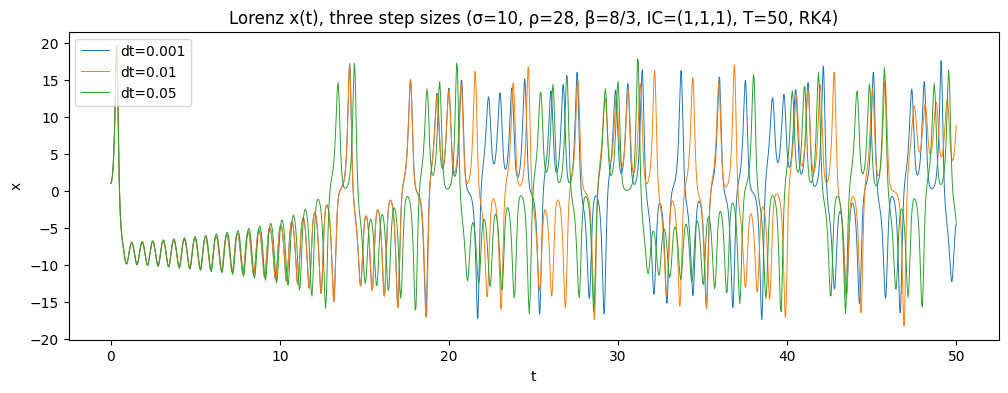

In [41]:
plt.figure(figsize=(12, 4))
for dt, (t_, tr) in runs.items():
    plt.plot(t_, tr[:,0], lw=0.7, label=f"dt={dt}")
plt.xlabel("t"); plt.ylabel("x"); plt.legend()
plt.title("Lorenz x(t), three step sizes (σ=10, ρ=28, β=8/3, IC=(1,1,1), T=50, RK4)")
plt.show()

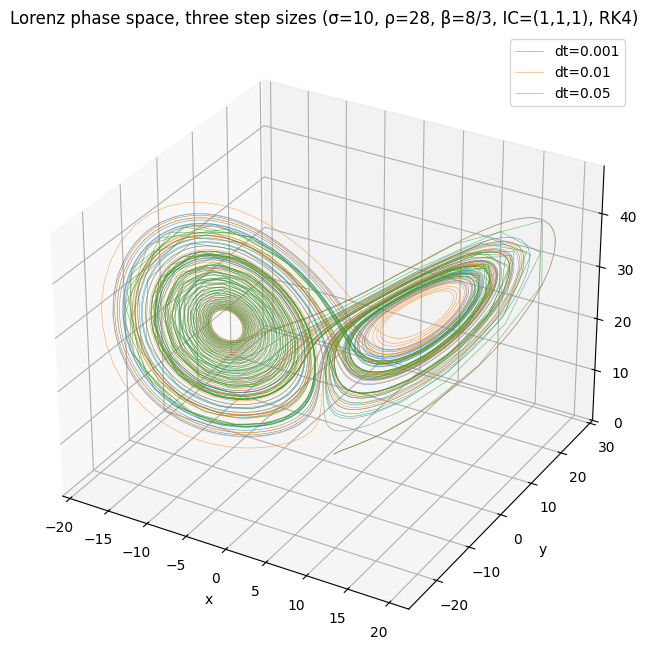

In [42]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection='3d')
for dt, (t_, tr) in runs.items():
    ax.plot(tr[:,0], tr[:,1], tr[:,2], lw=0.4, alpha=0.7, label=f"dt={dt}")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); ax.legend()
ax.set_title("Lorenz phase space, three step sizes (σ=10, ρ=28, β=8/3, IC=(1,1,1), RK4)")
plt.show()

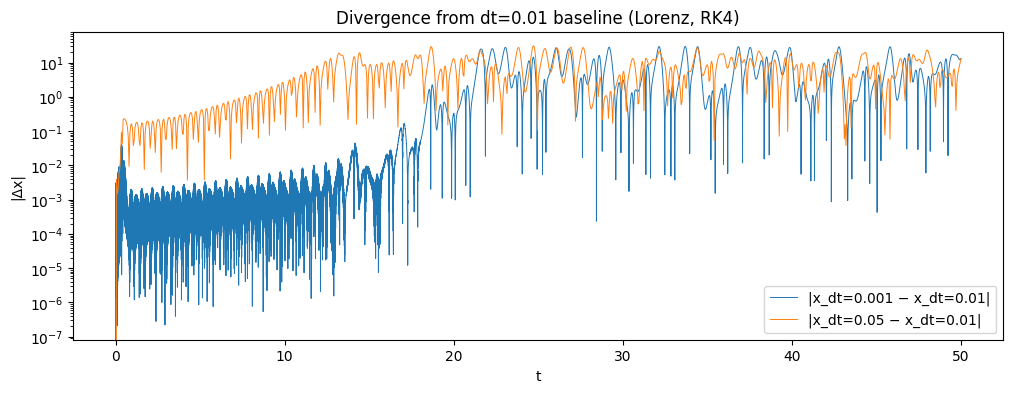

In [43]:
t_base, tr_base = runs[0.01]
plt.figure(figsize=(12, 4))
for dt in (0.001, 0.05):
    t_, tr = runs[dt]
    x_interp = np.interp(t_, t_base, tr_base[:,0])
    plt.plot(t_, np.abs(tr[:,0] - x_interp), lw=0.7, label=f"|x_dt={dt} − x_dt=0.01|")
plt.yscale('log'); plt.xlabel("t"); plt.ylabel("|Δx|"); plt.legend()
plt.title("Divergence from dt=0.01 baseline (Lorenz, RK4)")
plt.show()